# 23CSE301 Machine Learning — Capstone Project
## Clustering Track — Credit Card Customers (BankChurners)

**Track owner:** _(team member name — see `docs/team_contributions.md`)_
**Review:** Review 2 (full track)
**Dataset:** Credit Card Customers (BankChurners) — `BankChurners.csv`
**Source:** https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers

---

### How this notebook is organised
Every pipeline step calls the shared implementation in `src/`, which is the same
code that `scripts/run_all.py` executes. That keeps the notebook and the scripts
from drifting apart and means no result shown here is computed twice in two
different ways.

**On AI assistance:** code scaffolding in this project was generated with an AI
assistant (see `README.md` § AI-Assistance Disclosure). Every cell marked
**✍️ TEAM TO COMPLETE** must be written by the team. Those cells are empty on
purpose.

> ### ⚠️ The one rule that governs this whole notebook
> `Attrition_Flag` is **withheld**. It does not influence feature selection,
> scaling, the choice of *k*, or any fitting step. It is loaded once, kept aside,
> and cross-tabulated only in the final section — **after** the models are fixed.
> Clusters are not expected, and not required, to line up with churn.

## 0. Environment

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # project root on the path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loading as dl, preprocessing as pp
from src import feature_engineering as fe, evaluation as ev, plotting as pl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("default")      # warnings stay visible on purpose

print("random_state =", config.RANDOM_STATE, "| test_size =", config.TEST_SIZE,
      "| cv folds =", config.CV_FOLDS)

random_state = 42 | test_size = 0.2 | cv folds = 5


In [2]:
from src import clustering_models as cu
FEATURES = ['Customer_Age', 'Months_on_book', 'Total_Relationship_Count', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

## 1. Load, audit and feature selection

**The seven-feature subset is PROVISIONAL.** It was suggested as a starting
point; the team must record its own justification before it is final
(see `docs/team_analysis_prompts.md` Q-CL1). `CLIENTNUM` (an identifier) and the
two `Naive_Bayes_Classifier_...` columns (which the dataset author instructs
users to delete) are excluded.

In [3]:
raw = dl.load_raw("clustering")
summary = dl.audit_summary(raw, "clustering")
print("raw shape:", summary["shape"])
print("duplicates:", summary["n_duplicate_rows"], "| missing cells:", summary["total_missing_cells"])
print("\nfeature subset status:", config.CLUSTERING["feature_subset_status"])

[load_raw] dropping author-deprecated columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
[load_raw] clustering: BankChurners.csv -> shape (10127, 23) (expected (10127, 23))
raw shape: (10127, 23)
duplicates: 0 | missing cells: 0

feature subset status: PROVISIONAL - awaiting team justification


In [4]:
df = dl.prepare("clustering", raw)
holdout = dl.holdout_labels(raw)     # set aside, NOT used until section 8
assert "Attrition_Flag" not in df.columns and "CLIENTNUM" not in df.columns
df.describe().T

[prepare] clustering: raw (10127, 23) -> prepared (10127, 7) (7 columns kept)
  excluded: ['CLIENTNUM', 'Attrition_Flag', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Trans_Amt,10127.0,4404.086304,3397.129254,510.0,2155.500,3899.000,4741.000,18484.000
Total_Trans_Ct,10127.0,64.858695,23.472570,10.0,45.000,67.000,81.000,139.000
Avg_Utilization_Ratio,10127.0,0.274894,0.275691,0.0,0.023,0.176,0.503,0.999


> ### ✍️ TEAM TO COMPLETE — Feature subset justification (Q-CL1) — required
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Why these seven variables? What customer behaviour is each meant to capture?
> 2. Which candidate columns did you reject, and why (redundancy? identifier? derived from the label?)
> 3. Note that Credit_Limit, Avg_Open_To_Buy and Total_Revolving_Bal are algebraically related — how did that affect your choice?
>
> ---
>
> *(your written observation here)*

## 2. EDA

In [5]:
p = pl.distribution_grid(df, "BankChurners - clustering feature distributions",
                         "nb_clu_feature_distributions", "clustering")

[fig] results/figures/clustering/nb_clu_feature_distributions.png


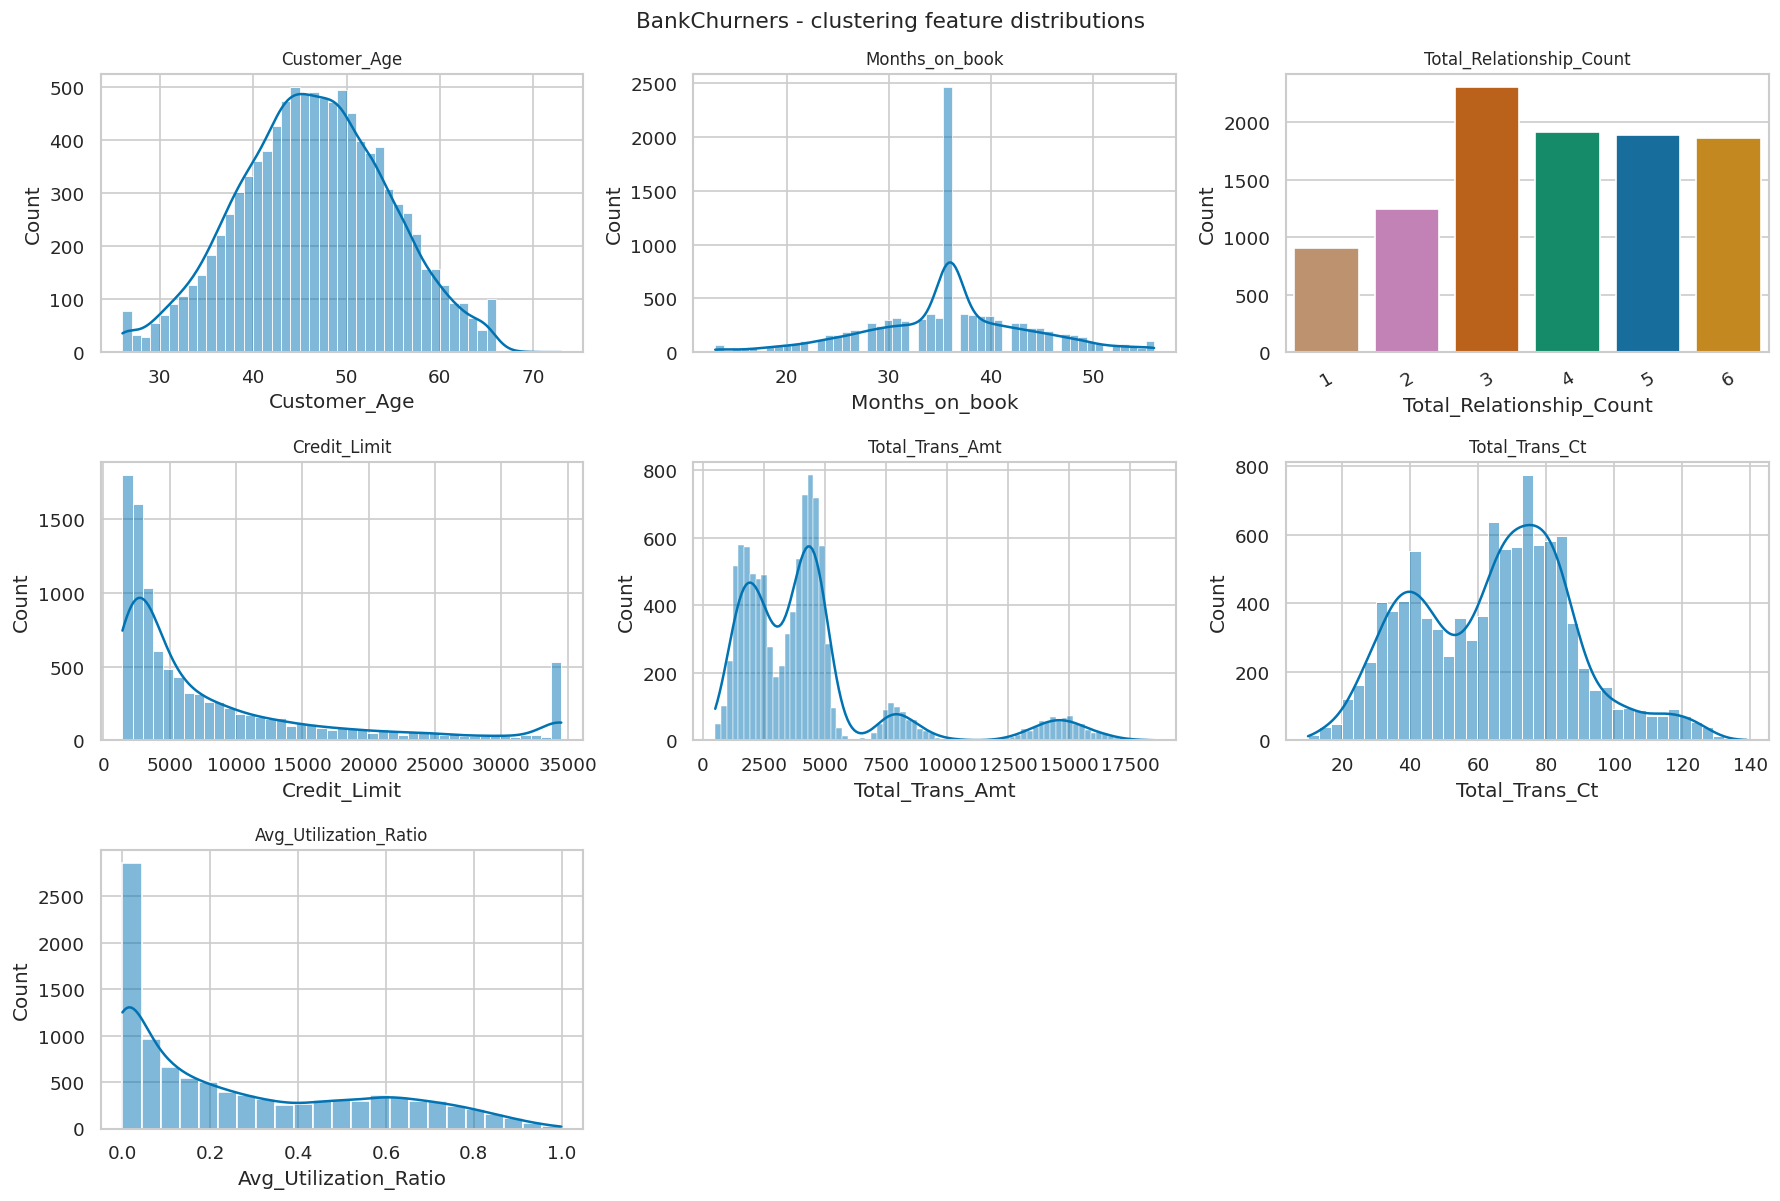

In [6]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [7]:
p = pl.correlation_heatmap(df, "BankChurners - correlation heatmap (clustering features)",
                           "nb_clu_correlation_heatmap", "clustering")

[fig] results/figures/clustering/nb_clu_correlation_heatmap.png


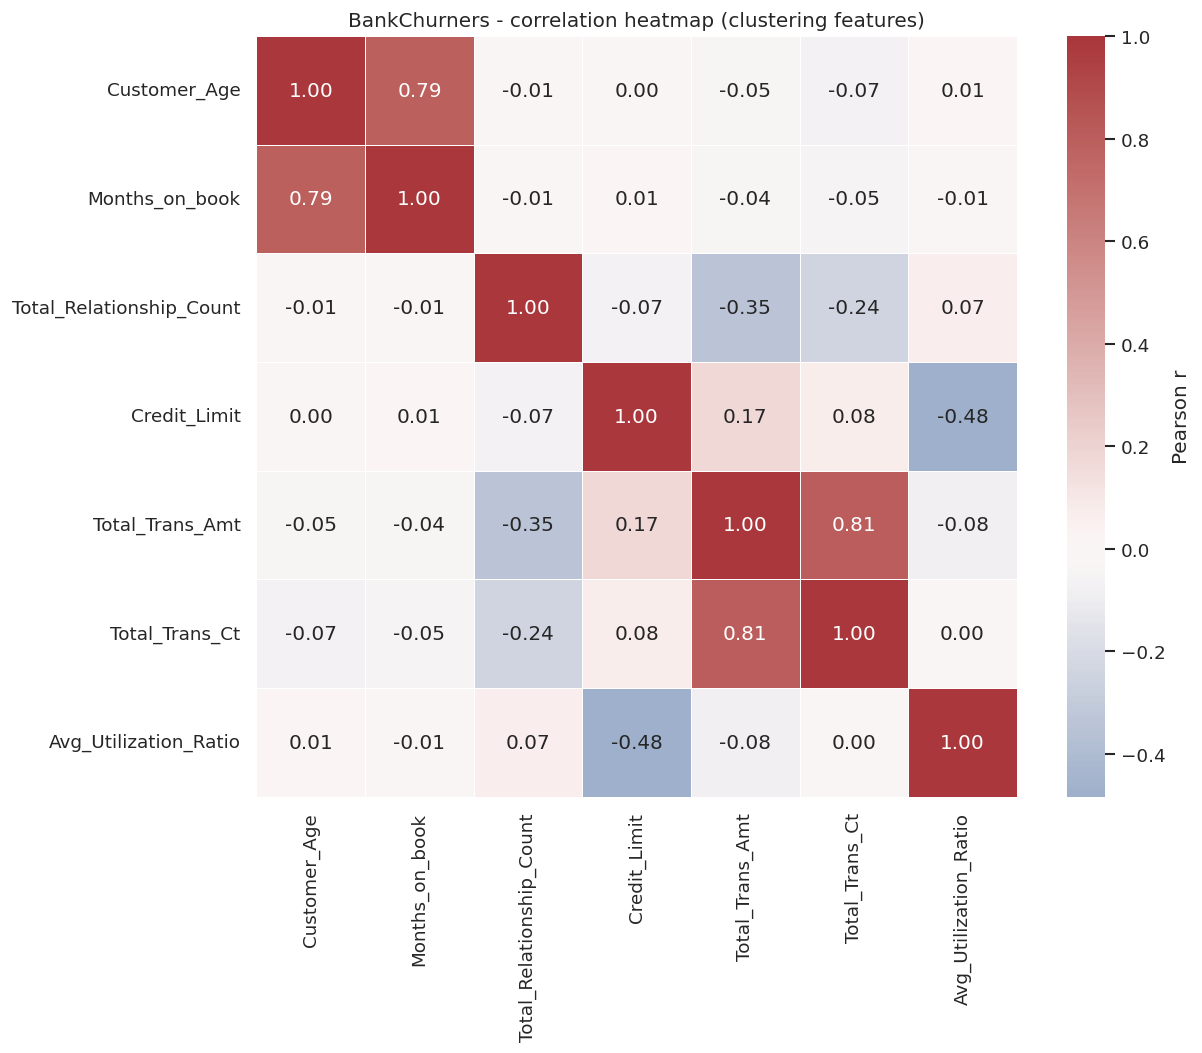

In [8]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Feature distributions and correlations
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which features are heavily skewed, and what does that do to a Euclidean distance?
> 2. Which pair is most correlated, and does that effectively double-count one behaviour in the distance calculation?
> 3. Would a log transform of any feature be justified? Say why or why not.
>
> ---
>
> *(your written observation here)*

## 3. Scaling and memory feasibility
Standardisation is mandatory here: `Credit_Limit` runs to five figures while
`Avg_Utilization_Ratio` lies in [0, 1], so without scaling the distance metric
would be decided almost entirely by credit limit.

Hierarchical clustering and the exact silhouette both build an *n × n*
structure, so the cost is checked before running them.

In [9]:
scaler = pp.make_cluster_preprocessor(list(df.columns))
X = scaler.fit_transform(df)
probe = cu.memory_probe(len(X))
probe

{'n_rows': 10127,
 'pairwise_matrix_GB': 0.764,
 'available_RAM_GB': 3.24,
 'feasible': True,
 'note': 'scipy/sklearn need roughly 2-3x the bare matrix during linkage'}

In [10]:
sil_sample = None if probe["feasible"] else 5000
print("scaled:", X.shape, "| exact silhouette:", sil_sample is None)

scaled: (10127, 7) | exact silhouette: True


## 4. K-Means — elbow curve and metric sweep  *(Rubric B1, B2)*

In [11]:
km_table, km_models = cu.kmeans_sweep(X, range(2, 11), silhouette_sample=sil_sample)
km_table

  k=2   inertia=     57331.2 sil=0.2954 DB=1.4020 CH=2394.4


  k=3   inertia=     47330.7 sil=0.1875 DB=1.6769 CH=2519.6


  k=4   inertia=     40986.8 sil=0.1895 DB=1.5139 CH=2461.8


  k=5   inertia=     36580.2 sil=0.1975 DB=1.4304 CH=2373.4


  k=6   inertia=     33624.4 sil=0.1872 DB=1.4711 CH=2243.3


  k=7   inertia=     31256.9 sil=0.1838 DB=1.4067 CH=2138.6


  k=8   inertia=     29338.9 sil=0.1844 DB=1.3347 CH=2047.2


  k=9   inertia=     27769.3 sil=0.1835 DB=1.3668 CH=1963.9


  k=10  inertia=     26389.4 sil=0.1864 DB=1.3779 CH=1895.6


,algorithm,k,inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,silhouette_exact,silhouette_sample_size
0,KMeans,2,57331.201202,0.295435,1.401951,2394.381662,True,full dataset
1,KMeans,3,47330.719291,0.187500,1.676914,2519.564093,True,full dataset
2,KMeans,4,40986.785628,0.189477,1.513879,2461.779285,True,full dataset
3,KMeans,5,36580.198928,0.197521,1.430388,2373.384374,True,full dataset
4,KMeans,6,33624.443655,0.187183,1.471109,2243.341658,True,full dataset
5,KMeans,7,31256.934654,0.183831,1.406651,2138.621449,True,full dataset
6,KMeans,8,29338.907432,0.184422,1.334719,2047.246930,True,full dataset
7,KMeans,9,27769.326048,0.183540,1.366757,1963.889101,True,full dataset
8,KMeans,10,26389.396291,0.186409,1.377897,1895.555119,True,full dataset


In [12]:
p = pl.elbow_plot(km_table["k"], km_table["inertia"], km_table["Silhouette"],
                  "nb_clu_kmeans_elbow", "clustering")
k_elbow = cu.elbow_knee(km_table["k"], km_table["inertia"])
k_sil = int(km_table.loc[km_table["Silhouette"].idxmax(), "k"])
print("elbow suggests k =", k_elbow, "| best silhouette at k =", k_sil)

[fig] results/figures/clustering/nb_clu_kmeans_elbow.png
elbow suggests k = 5 | best silhouette at k = 2


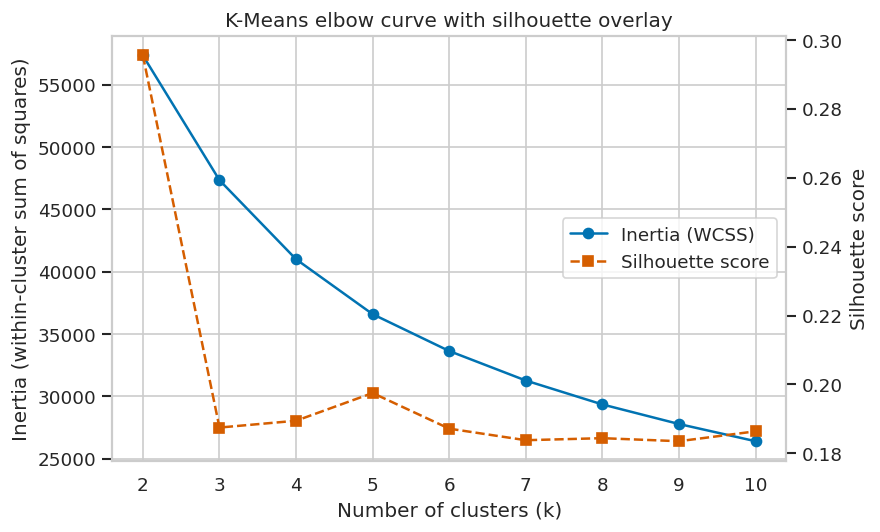

In [13]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Choosing k (Q-CL2) — required
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Where do YOU read the elbow? Is it sharp or gradual?
> 2. The elbow and the silhouette maximum may disagree. Which do you follow, and why?
> 3. Does a larger k give you clusters that are actually describable in business terms, or just smaller ones?
> 4. State your chosen k and your reason. The code below uses the numerical elbow as a placeholder.
>
> ---
>
> *(your written observation here)*

In [14]:
k_final = k_elbow          # TEAM: replace with your chosen k once decided
print("k used below:", k_final)
km_final = km_models[k_final]
km_labels = km_final.labels_

k used below: 5


## 5. Agglomerative hierarchical clustering  *(Rubric B1, B2)*
Linkage strategies are compared, and the dendrogram is drawn from the **actual
fitted hierarchy** (display truncated to the last 30 merges so the leaves stay
legible — the hierarchy itself is complete).

In [15]:
link_cmp = cu.linkage_comparison(X, k_final, silhouette_sample=sil_sample)
link_cmp

  linkage=ward      sil=0.1612 DB=1.6437 CH=1944.1


  linkage=complete  sil=0.1377 DB=1.9234 CH=1492.8


  linkage=average   sil=0.1619 DB=1.1799 CH=966.0


  linkage=single    sil=0.1379 DB=0.6152 CH=3.7


,algorithm,linkage,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,silhouette_exact,silhouette_sample_size
0,Agglomerative,ward,5,0.161177,1.643720,1944.083969,True,full dataset
1,Agglomerative,complete,5,0.137679,1.923445,1492.763806,True,full dataset
2,Agglomerative,average,5,0.161854,1.179906,965.956234,True,full dataset
3,Agglomerative,single,5,0.137852,0.615173,3.728856,True,full dataset


> ### ✍️ TEAM TO COMPLETE — Linkage comparison
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which linkage scores best on silhouette, and which on Davies-Bouldin? Do they agree?
> 2. Single linkage often produces one huge cluster and several tiny ones. Check the cluster sizes — did that happen here, and why is its metric score misleading if so?
> 3. Which linkage do you adopt, and why?
>
> ---
>
> *(your written observation here)*

In [16]:
agg_table, agg_models = cu.agglomerative_sweep(X, range(2, 11), linkage="ward",
                                               silhouette_sample=sil_sample)
agg_model, agg_labels = agg_models[k_final]
agg_table

  k=2   sil=0.3571 DB=1.0837 CH=1971.3


  k=3   sil=0.1484 DB=1.9310 CH=1888.9


  k=4   sil=0.1492 DB=1.6827 CH=1973.6


  k=5   sil=0.1612 DB=1.6437 CH=1944.1


  k=6   sil=0.1337 DB=1.5461 CH=1823.3


  k=7   sil=0.1296 DB=1.5749 CH=1729.5


  k=8   sil=0.1299 DB=1.5409 CH=1671.8


  k=9   sil=0.1269 DB=1.6021 CH=1584.3


  k=10  sil=0.1213 DB=1.6579 CH=1521.0


,algorithm,linkage,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,silhouette_exact,silhouette_sample_size
0,Agglomerative,ward,2,0.357103,1.083692,1971.271874,True,full dataset
1,Agglomerative,ward,3,0.148441,1.931021,1888.884875,True,full dataset
2,Agglomerative,ward,4,0.149207,1.682692,1973.600242,True,full dataset
3,Agglomerative,ward,5,0.161177,1.643720,1944.083969,True,full dataset
4,Agglomerative,ward,6,0.133660,1.546123,1823.318090,True,full dataset
5,Agglomerative,ward,7,0.129581,1.574875,1729.496333,True,full dataset
6,Agglomerative,ward,8,0.129939,1.540899,1671.831120,True,full dataset
7,Agglomerative,ward,9,0.126867,1.602059,1584.295381,True,full dataset
8,Agglomerative,ward,10,0.121336,1.657862,1520.984416,True,full dataset


In [17]:
p = pl.dendrogram_plot(X, "ward", "nb_clu_dendrogram_ward", "clustering", truncate_p=30)

[fig] results/figures/clustering/nb_clu_dendrogram_ward.png


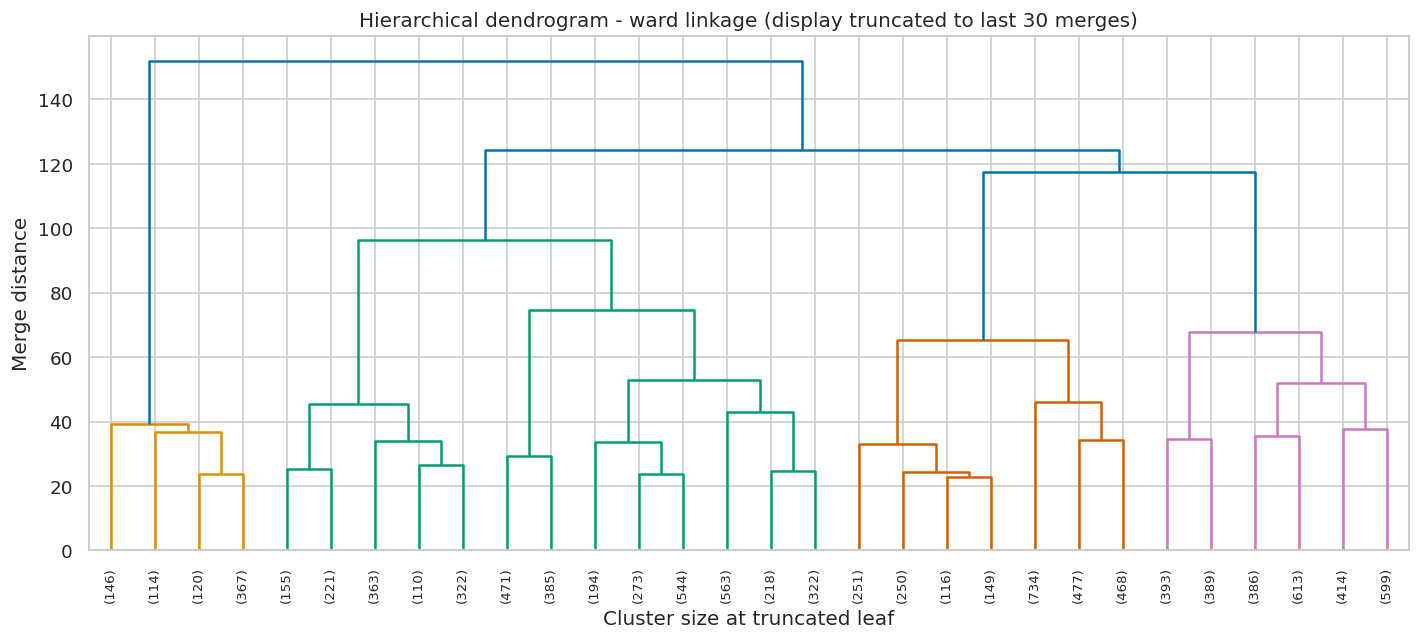

In [18]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Dendrogram
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. At what merge distance would a horizontal cut give you your chosen k?
> 2. Do the branch heights suggest a natural number of clusters, or a smooth continuum?
> 3. Are the cluster sizes at the cut balanced?
>
> ---
>
> *(your written observation here)*

## 6. Headline metrics for both algorithms  *(Rubric B2)*
Silhouette, Davies-Bouldin and Calinski-Harabasz for K-Means and Agglomerative
at the same k.

In [19]:
rows = []
for algo, labels in (("K-Means", km_labels), ("Agglomerative (ward)", agg_labels)):
    m = ev.clustering_metrics(X, labels, sample_size=sil_sample)
    m["algorithm"] = algo; m["k"] = k_final
    rows.append(m)
final = pd.DataFrame(rows)[["algorithm","k","n_clusters","Silhouette",
                            "Davies_Bouldin","Calinski_Harabasz","silhouette_exact"]]
final

,algorithm,k,n_clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,silhouette_exact
0,K-Means,5,5,0.197521,1.430388,2373.384374,True
1,Agglomerative (ward),5,5,0.161177,1.643720,1944.083969,True


> ### ✍️ TEAM TO COMPLETE — Metric comparison
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Higher silhouette and Calinski-Harabasz are better; LOWER Davies-Bouldin is better. Do all three agree on which algorithm wins?
> 2. The absolute silhouette values here are low. What does that say about whether this customer base has genuinely separated groups or a continuum?
> 3. Would you describe the result as 'clusters found' or 'a partition imposed'? Defend your answer.
>
> ---
>
> *(your written observation here)*

## 7. Cluster visualisation  *(Rubric B3)*

**Important:** both algorithms were fitted on the full 7-dimensional standardised
space. PCA and t-SNE below are **projections for viewing only** — no model was
fitted on two components.

In [20]:
coords, pca = cu.pca_embedding(X, 2)
evr = pca.explained_variance_ratio_
note = (f"PCA is for VISUALISATION only; clustering was fitted on all 7 standardised "
        f"features. PC1+PC2 explain {evr.sum()*100:.1f}% of variance.")
p1 = pl.cluster_scatter_2d(coords, km_labels, f"K-Means (k={k_final}) - PCA projection",
                           "nb_clu_pca_kmeans", "clustering",
                           xlabel=f"PC1 ({evr[0]*100:.1f}% var)",
                           ylabel=f"PC2 ({evr[1]*100:.1f}% var)", note=note)
p2 = pl.cluster_scatter_2d(coords, agg_labels, f"Agglomerative ward (k={k_final}) - PCA projection",
                           "nb_clu_pca_agglomerative", "clustering",
                           xlabel=f"PC1 ({evr[0]*100:.1f}% var)",
                           ylabel=f"PC2 ({evr[1]*100:.1f}% var)", note=note)

  [PCA] explained variance ratio: [0.2965 0.2533] (cumulative 0.5497)


[fig] results/figures/clustering/nb_clu_pca_kmeans.png


[fig] results/figures/clustering/nb_clu_pca_agglomerative.png


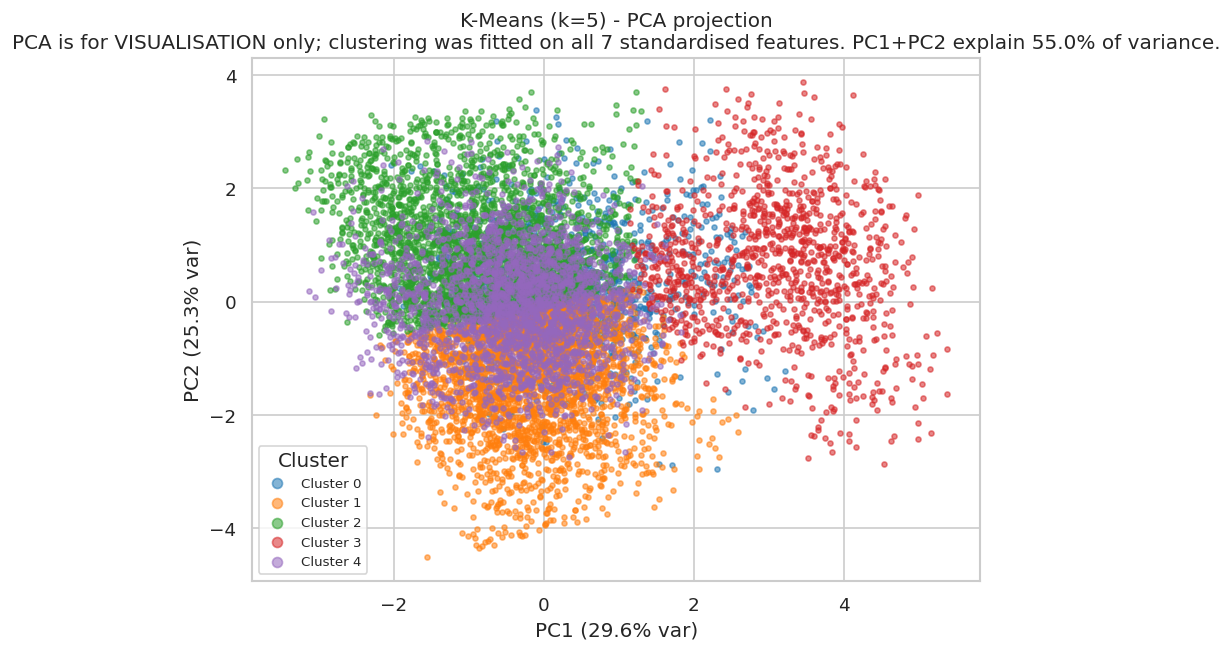

In [21]:
from IPython.display import Image, display
display(Image(filename=str(p1)))

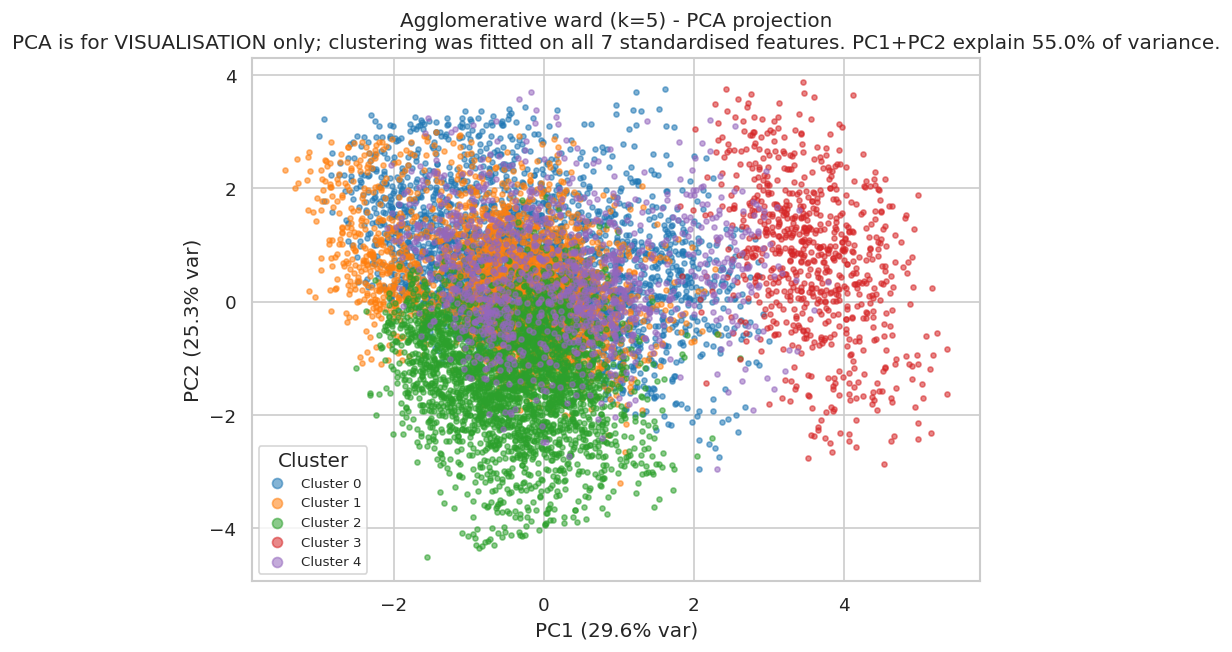

In [22]:
from IPython.display import Image, display
display(Image(filename=str(p2)))

In [23]:
tc, tl, tnote = cu.tsne_embedding(X, km_labels, sample_size=3000)
print(tnote)
p = pl.cluster_scatter_2d(tc, tl, f"K-Means (k={k_final}) - t-SNE projection",
                          "nb_clu_tsne_kmeans", "clustering",
                          xlabel="t-SNE 1", ylabel="t-SNE 2", note=tnote)

SAMPLED: 3000 of 10127 rows (visualisation only)
[fig] results/figures/clustering/nb_clu_tsne_kmeans.png


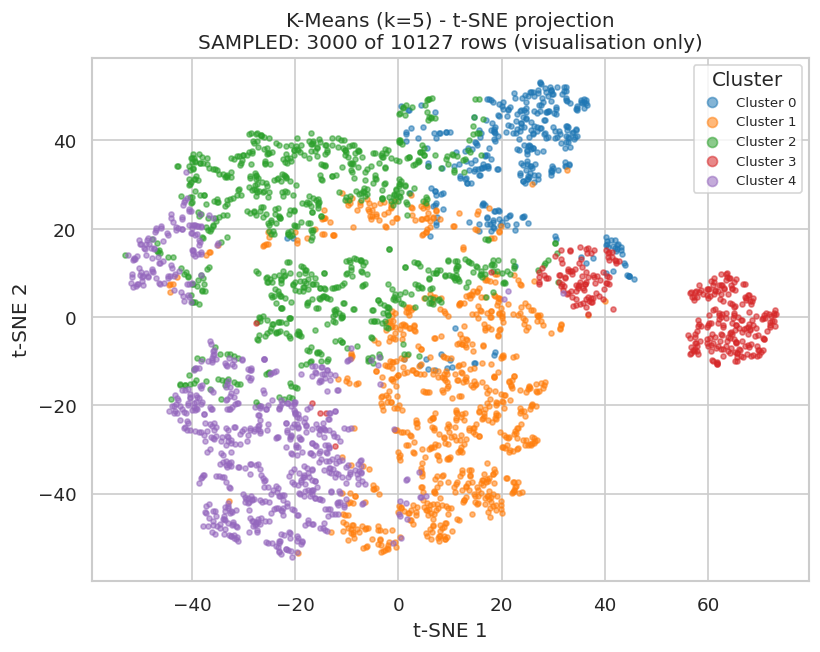

In [24]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Reading the projections
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Do the clusters look separated in the PCA view, or do they mostly tile a single cloud? Remember PC1+PC2 capture only part of the variance.
> 2. Does t-SNE show more separation than PCA? Why can t-SNE exaggerate separation, and what does that mean for how much you should trust it?
> 3. Do K-Means and Agglomerative carve the space in a similar way?
>
> ---
>
> *(your written observation here)*

## 8. Supplementary validation and post-hoc label check

### 8.1 Resampling stability — **not** cross-validation
The PDF asks for cross-validation in every track. Ordinary k-fold CV has no
direct meaning for `AgglomerativeClustering`, which cannot assign unseen points.
What follows is **supplementary evidence only** and does not itself satisfy that
rubric wording — logged as `IC-3` in `docs/instructor_clarifications.md`.
Overlapping subsamples are clustered independently and the label agreement on
the overlap is measured with the Adjusted Rand Index.

In [25]:
stab = [cu.stability_assessment(X, k_final, "kmeans", n_repeats=20),
        cu.stability_assessment(X, k_final, "agglomerative", n_repeats=20)]
pd.DataFrame(stab)

,algorithm,k,n_repeats_completed,subsample_frac,mean_ARI,std_ARI,min_ARI,interpretation_status
0,kmeans,5,20,0.8,0.866884,0.129772,0.627543,SUPPLEMENTARY - not supervised cross-validation
1,agglomerative,5,20,0.8,0.306559,0.058626,0.201324,SUPPLEMENTARY - not supervised cross-validation


> ### ✍️ TEAM TO COMPLETE — Stability
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. ARI of 1.0 means identical partitions, 0.0 means chance agreement. How reproducible is each algorithm's partition?
> 2. If one algorithm is markedly less stable, what does that say about trusting its cluster descriptions?
>
> ---
>
> *(your written observation here)*

### 8.2 Cluster profiles — the basis for your interpretation
Mean of each **original, unscaled** feature per cluster.

In [26]:
for algo, labels in (("K-Means", km_labels), ("Agglomerative", agg_labels)):
    print(f"\n=== {algo} ===")
    display(cu.cluster_profile(df, labels))


=== K-Means ===


,n_members,pct_of_data,Customer_Age,Months_on_book,Total_Relationship_Count,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
cluster,,,,,,,,,
0,1219,12.04,46.267,35.876,3.970,26920.160,3514.607,58.625,0.044
1,2701,26.67,38.516,28.696,4.248,5788.735,3219.945,58.766,0.212
2,2726,26.92,53.445,42.558,3.982,6323.555,3002.979,54.193,0.163
3,1102,10.88,45.371,35.213,2.129,13889.142,12570.282,103.865,0.166
4,2379,23.49,47.508,36.902,3.823,2698.992,4027.000,69.123,0.643



=== Agglomerative ===


,n_members,pct_of_data,Customer_Age,Months_on_book,Total_Relationship_Count,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
cluster,,,,,,,,,
0,2970,29.33,50.043,39.271,3.316,6822.143,3836.906,62.397,0.109
1,2445,24.14,49.699,38.986,3.888,2790.342,3993.621,68.271,0.611
2,2794,27.59,39.431,29.526,4.666,6384.160,2996.449,55.599,0.278
3,747,7.38,45.102,35.012,2.357,14053.798,14698.396,110.336,0.180
4,1171,11.56,47.088,36.927,3.806,27323.754,3491.362,57.061,0.047


> ### ✍️ TEAM TO COMPLETE — Cluster interpretation (Q-CL3) — required, the heart of this track
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Give each K-Means cluster a short descriptive NAME based on its profile row.
> 2. For each cluster, name the two or three features that most distinguish it from the overall average.
> 3. Which cluster would a bank care about most, and what action would you recommend for it?
> 4. Do any two clusters differ so little that you would merge them?
>
> ---
>
> *(your written observation here)*

### 8.3 Post-hoc check against the withheld label
Run **only now**, after k and the models were fixed. This is validation, not
optimisation — and the clusters were never meant to reproduce churn.

In [27]:
ct = cu.posthoc_label_crosstab(km_labels, holdout)
ct

Attrition_Flag,Attrited Customer,Existing Customer,row_pct_attrited
cluster,,,
0,216,1003,17.72
1,514,2187,19.03
2,653,2073,23.95
3,50,1052,4.54
4,194,2185,8.15


> ### ✍️ TEAM TO COMPLETE — Post-hoc validation (Q-CL4)
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Does any cluster show a notably higher attrition rate than the overall rate?
> 2. If clusters do NOT align with churn, is the clustering therefore useless? Argue your position.
> 3. Why would it have been methodologically wrong to use this table to pick k?
>
> ---
>
> *(your written observation here)*

## 9. Clustering track conclusion

> ### ✍️ TEAM TO COMPLETE — Clustering conclusion
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Summarise: which algorithm, which k, which metrics, and what the clusters mean in business terms.
> 2. What is the strongest argument AGAINST your own conclusion?
> 3. What extra data would make this segmentation more convincing?
>
> ---
>
> *(your written observation here)*